# Exploratory Data Analysis

This notebook explores the four tables that the household contents-value regression uses. They come from the workbook `myVal_Synthetic_Datasets_release_v2.xlsx`, which is stored in `data/raw/`.

| Table | One row is… |
|---|---|
| `customers` | one customer |
| `customer_profiles` | profile and behaviour attributes of one customer |
| `properties` | one property (a "household" or home) |
| `assets` | one household item (the item data is real AI output) |

The workbook contains 25 tabs in total, such as claims, policies and valuations, and the last section of this notebook lists all of them. Only the four tables above are analysed, because they are the ones the regression uses.

**Questions this notebook answers**
1. How many customers and how many properties (households) are there, and how many properties does each customer have?
2. What do the vehicles look like in terms of average value, number per home and type?
3. What does each table contain in terms of distributions, missing values and data-quality checks?
4. How does the contents value of a home relate to the property and customer attributes?
5. Can the basket simulation (N = 10, 20, 30, 50) work, in other words are there enough items per home?

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

XLSX = Path("../../data/raw/myVal_Synthetic_Datasets_release_v2.xlsx")
CACHE = Path("../../data/interim/regression")
CACHE.mkdir(parents=True, exist_ok=True)   # parquet copy of the sheets, shared with the data preparation notebook

def load(sheet):
    f = CACHE / f"{sheet}.parquet"          # reading xlsx is slow, so cache each sheet as parquet
    if f.exists(): return pd.read_parquet(f)
    d = pd.read_excel(XLSX, sheet_name=sheet)
    d.to_parquet(f, index=False)
    return d

assets, properties, customers, profiles = load("assets"), load("properties"), load("customers"), load("customer_profiles")


pd.set_option("display.max_columns", 40, "display.width", 200)
plt.rcParams.update({"figure.figsize": (7, 3.4), "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED = "#3d5a80", "#d1495b"

def bar(s, title, xlabel="", horizontal=False, color=BLUE, pct=False, figsize=None):
    s = s.copy()
    fig, ax = plt.subplots(figsize=figsize or ((7, max(2.5, 0.28 * len(s) + 1)) if horizontal else (7, 3.4)))
    (s.plot.barh if horizontal else s.plot.bar)(ax=ax, color=color)
    if horizontal: ax.invert_yaxis()
    for p in ax.patches:
        v = p.get_width() if horizontal else p.get_height()
        txt = f"{v:.1f}%" if pct else f"{v:,.0f}"
        if horizontal: ax.text(v, p.get_y() + p.get_height() / 2, " " + txt, va="center", fontsize=8)
        else: ax.text(p.get_x() + p.get_width() / 2, v, txt, ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel) if horizontal else ax.set_xlabel(xlabel)
    if not horizontal: plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

def profile(df, name):
    out = pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum(), "nulls": df.isna().sum(),
                        "unique": df.nunique(), "example": df.iloc[0]})
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(out)

## 1. Overview and data-quality checks

In [2]:
for df, name in [(customers, "customers"), (profiles, "customer_profiles"), (properties, "properties"), (assets, "assets")]:
    profile(df, name)

customers: 500 rows x 15 columns


,dtype,non_null,nulls,unique,example
Customer_ID,str,500,0,500,CUS-00001
Age_Band,str,500,0,6,25-34
Gender,str,500,0,3,Female
City,str,500,0,51,Adelaide
State,str,500,0,8,SA
Country,str,500,0,1,Australia
Postcode,int64,500,0,51,5000
Occupation,str,500,0,32,Barista
Account_Created,str,500,0,500,2023-02-17 14:52:34
Membership_Level,str,500,0,3,free


customer_profiles: 500 rows x 15 columns


,dtype,non_null,nulls,unique,example
Customer_ID,str,500,0,500,CUS-00001
Financial_Literacy_Band,str,500,0,3,high
Insurance_Confidence_1_5,int64,500,0,5,3
Engagement_Tier,str,500,0,4,power
Preferred_Channel,str,500,0,4,phone
Preferred_Explanation_Style,str,500,0,4,short_summary
Notification_Opt_In,bool,500,0,2,True
Accessibility_Need,str,500,0,4,none
Language_At_Home,str,500,0,9,English
Household_Type,str,500,0,5,single


properties: 795 rows x 19 columns


,dtype,non_null,nulls,unique,example
Property_ID,str,795,0,795,PRP-000001
Customer_ID,str,795,0,500,CUS-00001
Property_Type,str,795,0,6,house
Occupancy_Type,str,795,0,2,owner
Number_Of_Occupants,int64,795,0,8,2
Number_Of_Bedrooms,int64,795,0,8,3
Address_Locality,str,795,0,51,Adelaide
Address_State,str,795,0,8,SA
Address_Postcode,int64,795,0,51,5000
Address_Country,str,795,0,1,Australia


assets: 8,309 rows x 26 columns


,dtype,non_null,nulls,unique,example
Asset_ID,str,8309,0,8309,AST-0000001
Customer_ID,str,8309,0,500,CUS-00158
Property_ID,str,8309,0,795,PRP-000181
Policy_ID,str,4833,3476,422,NaN
Category_ID,str,8309,0,7,CAT-001
Category,str,8309,0,7,Electronics
Asset_Name,str,8309,0,5749,Unidentified item
Brand,str,7464,845,2028,NaN
Model,float64,0,8309,0,NaN
Year,float64,1048,7261,33,NaN


In [3]:
# Key integrity checks
checks = {
    "customers: Customer_ID unique": customers.Customer_ID.is_unique,
    "customer_profiles: Customer_ID unique": profiles.Customer_ID.is_unique,
    "properties: Property_ID unique": properties.Property_ID.is_unique,
    "assets: Asset_ID unique": assets.Asset_ID.is_unique,
    "customers and profiles cover the same customers": set(customers.Customer_ID) == set(profiles.Customer_ID),
    "every property's customer exists in customers": properties.Customer_ID.isin(customers.Customer_ID).all(),
    "every asset's property exists in properties": assets.Property_ID.isin(properties.Property_ID).all(),
    "every asset's customer exists in customers": assets.Customer_ID.isin(customers.Customer_ID).all(),
}
# does the asset's Customer_ID agree with its property's owner?
owner = properties.set_index("Property_ID").Customer_ID
checks["asset.Customer_ID == owner of asset.Property_ID"] = (assets.Customer_ID == assets.Property_ID.map(owner)).all()
checks["every customer has >= 1 property"] = customers.Customer_ID.isin(properties.Customer_ID).all()
display(pd.Series(checks, name="passes?").to_frame())

,passes?
customers: Customer_ID unique,True
customer_profiles: Customer_ID unique,True
properties: Property_ID unique,True
assets: Asset_ID unique,True
customers and profiles cover the same customers,True
every property's customer exists in customers,True
every asset's property exists in properties,True
every asset's customer exists in customers,True
asset.Customer_ID == owner of asset.Property_ID,True
every customer has >= 1 property,True


## 2. Customers and households (properties)

A **household** in this project is one property (`Property_ID`), which is also what the model treats as one home. A customer can own several properties, so the number of households is always greater than or equal to the number of customers (**#households ≥ #customers**).

customers: 500 | properties (households): 795 | assets: 8,309
average properties per customer: 1.59
average items per property (all categories): 10.5


,customers,share_%,properties
properties owned by customer,,,
1,297,59.4,297
2,134,26.8,268
3,51,10.2,153
4,14,2.8,56
5,3,0.6,15
6,1,0.2,6


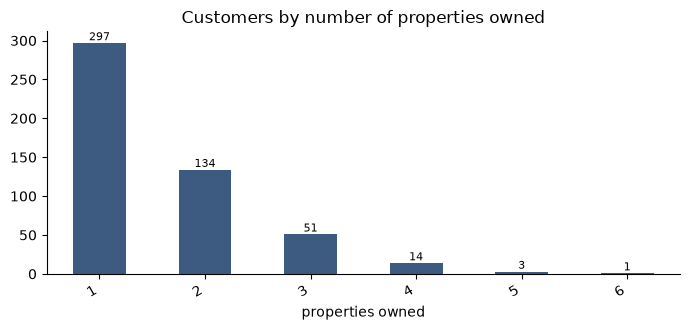

In [4]:
n_cust, n_prop, n_asset = customers.Customer_ID.nunique(), properties.Property_ID.nunique(), len(assets)
print(f"customers: {n_cust} | properties (households): {n_prop} | assets: {n_asset:,}")
print(f"average properties per customer: {n_prop / n_cust:.2f}")
print(f"average items per property (all categories): {n_asset / n_prop:.1f}")

per_cust = properties.groupby("Customer_ID").size().rename("n_properties")
dist = per_cust.value_counts().sort_index().rename("customers").to_frame()
dist["share_%"] = (100 * dist.customers / dist.customers.sum()).round(1)
dist["properties"] = dist.index * dist.customers
dist.index.name = "properties owned by customer"
display(dist)
bar(dist["customers"], "Customers by number of properties owned", "properties owned")

customers with >1 property: 203 | with more than one distinct type: 66


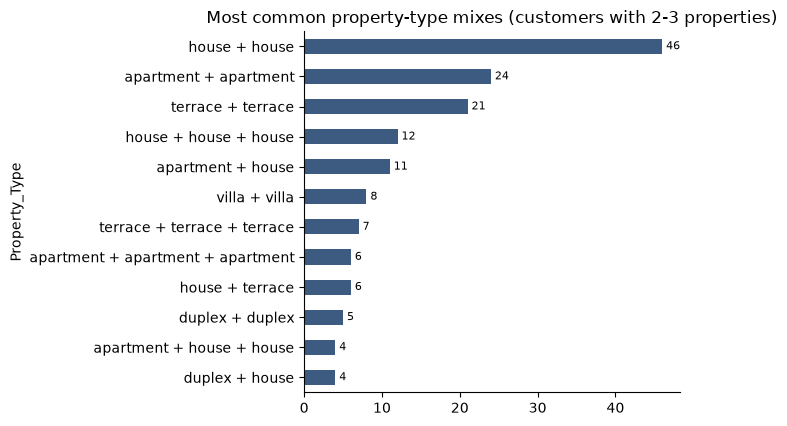

Customers with the maximum number of properties (6):


,Customer_ID,Property_ID,Property_Type,Occupancy_Type,Number_Of_Bedrooms,Is_Primary
308,CUS-00265,PRP-000309,terrace,owner,3,True
309,CUS-00265,PRP-000310,house,tenant,2,False
626,CUS-00265,PRP-000627,house,tenant,1,False
650,CUS-00265,PRP-000651,terrace,owner,3,False
691,CUS-00265,PRP-000692,terrace,owner,3,False
697,CUS-00265,PRP-000698,house,tenant,3,False


In [5]:
# Customers with several properties: which property types do they mix?
multi = properties[properties.Customer_ID.isin(per_cust[per_cust > 1].index)]
combo = multi.groupby("Customer_ID").Property_Type.agg(lambda s: " + ".join(sorted(s)))
print(f"customers with >1 property: {len(combo)} | with more than one distinct type: {(multi.groupby('Customer_ID').Property_Type.nunique() > 1).sum()}")
bar(combo.value_counts().head(12), "Most common property-type mixes (customers with 2-3 properties)", horizontal=True)

print(f"Customers with the maximum number of properties ({per_cust.max()}):")
three = per_cust[per_cust == per_cust.max()].index
display(properties[properties.Customer_ID.isin(three)].head(45).sort_values(["Customer_ID", "Is_Primary"], ascending=[True, False])
        [["Customer_ID", "Property_ID", "Property_Type", "Occupancy_Type", "Number_Of_Bedrooms", "Is_Primary"]])

In [6]:
# Primary flag and how many properties each customer has
display(pd.crosstab(properties.Is_Primary, properties.Customer_ID.map(per_cust), margins=True)
        .rename_axis(index="Is_Primary", columns="customer's #properties"))
print("Each customer has exactly one primary property:", (properties.groupby("Customer_ID").Is_Primary.sum() == 1).all())

customer's #properties,1,2,3,4,5,6,All
Is_Primary,,,,,,,
False,0,134,102,42,12,5,295
True,297,134,51,14,3,1,500
All,297,268,153,56,15,6,795


Each customer has exactly one primary property: True


## 3. Vehicles

Vehicles are the category **`Vehicles`** in `assets`. The data preparation notebook (`02_ky_data_preparation`) removes them before building the target because they are not normal contents and have a very high average value.

In [7]:
veh = assets[assets.Category == "Vehicles"].copy()
non = assets[assets.Category != "Vehicles"]
veh["Vehicle_Type"] = veh.Asset_Name.str.replace(r"\s*\(.*", "", regex=True)

n_veh_props = veh.Property_ID.nunique()
print(f"vehicle items: {len(veh):,} ({100*len(veh)/len(assets):.1f}% of all assets)")
print(f"properties owning >=1 vehicle: {n_veh_props} of {n_prop} ({100*n_veh_props/n_prop:.1f}%)")
print(f"customers owning >=1 vehicle:  {veh.Customer_ID.nunique()} of {n_cust} ({100*veh.Customer_ID.nunique()/n_cust:.1f}%)")
print(f"average vehicles per property that owns any: {len(veh)/n_veh_props:.2f}")
print(f"average vehicles per property (all properties): {len(veh)/n_prop:.2f}")
print(f"average vehicles per customer (all customers): {len(veh)/n_cust:.2f}")
print()
v = veh.Current_Estimated_Value
nv = non.Current_Estimated_Value
print(f"average vehicle value:       ${v.mean():>9,.0f}   (median ${v.median():,.0f}, min ${v.min():,.0f}, max ${v.max():,.0f})")
print(f"average non-vehicle value:   ${nv.mean():>9,.0f}   (median ${nv.median():,.0f})   -> a vehicle is ~{v.mean()/nv.mean():.0f}x an average item")
vp = veh.groupby("Property_ID").Current_Estimated_Value.sum()
print(f"average total vehicle value per vehicle-owning property: ${vp.mean():,.0f}")

vehicle items: 22 (0.3% of all assets)
properties owning >=1 vehicle: 16 of 795 (2.0%)
customers owning >=1 vehicle:  16 of 500 (3.2%)
average vehicles per property that owns any: 1.38
average vehicles per property (all properties): 0.03
average vehicles per customer (all customers): 0.04

average vehicle value:       $   42,998   (median $19,500, min $450, max $250,000)
average non-vehicle value:   $    1,594   (median $500)   -> a vehicle is ~27x an average item
average total vehicle value per vehicle-owning property: $59,122


,items,avg_value,median_value,min_value,max_value,avg_purchase_price
Vehicle_Type,,,,,,
Airfryer XXL,1,450.0,450.0,450.0,450.0,NaN
BMW X1,1,60000.0,60000.0,60000.0,60000.0,NaN
Captiva,1,10000.0,10000.0,10000.0,10000.0,NaN
City Bus - Generic,1,250000.0,250000.0,250000.0,250000.0,NaN
Dualis,1,10000.0,10000.0,10000.0,10000.0,NaN
H6,1,21000.0,21000.0,21000.0,21000.0,NaN
HiAce Van,1,7000.0,7000.0,7000.0,7000.0,NaN
Hilux Ute,1,35000.0,35000.0,35000.0,35000.0,NaN
Kodiaq,1,55000.0,55000.0,55000.0,55000.0,NaN


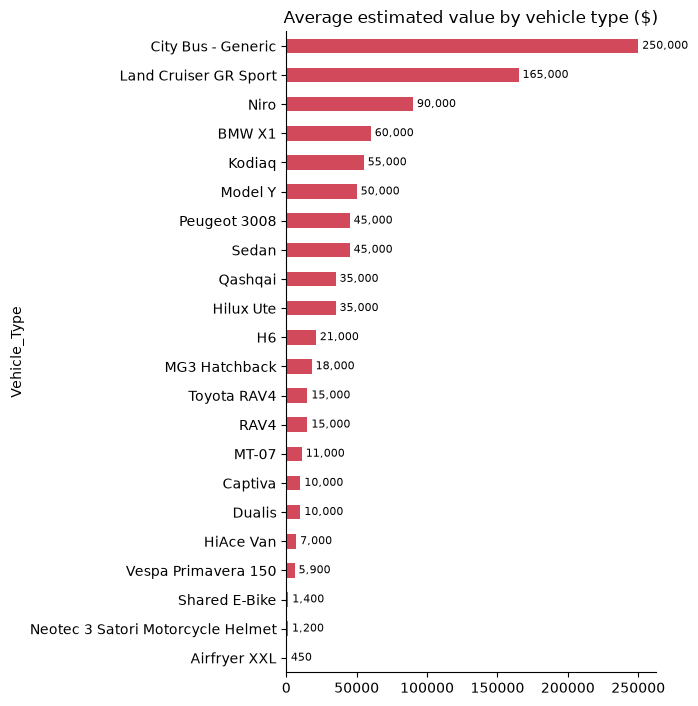

In [8]:
bytype = veh.groupby("Vehicle_Type").Current_Estimated_Value.agg(items="count", avg_value="mean", median_value="median", min_value="min", max_value="max").sort_values("items", ascending=False).round(0)
bytype["avg_purchase_price"] = veh.groupby("Vehicle_Type").Purchase_Price.mean().round(0)
display(bytype)
bar(bytype["avg_value"].sort_values(ascending=False), "Average estimated value by vehicle type ($)", horizontal=True, color=RED)

,properties,share_%
vehicles in property,,
0,779,98.0
1,11,1.4
2,4,0.5
3,1,0.1


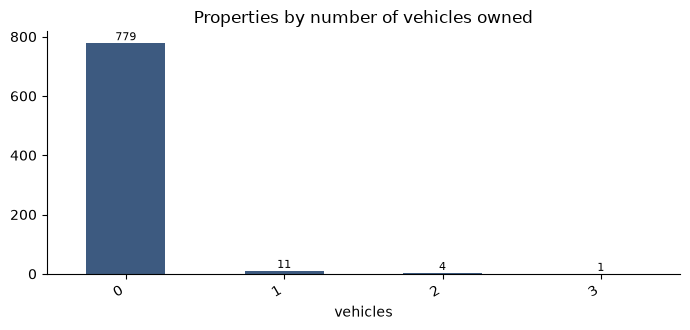

,properties,share_with_vehicle
Property_Type,,
house,329,1.5
apartment,188,3.2
terrace,162,1.9
villa,60,3.3
duplex,39,0.0
semi-detached,17,0.0


,properties,share_with_vehicle
Occupancy_Type,,
owner,480,2.3
tenant,315,1.6


In [9]:
n_per_prop = veh.groupby("Property_ID").size().reindex(properties.Property_ID).fillna(0).astype(int)
d = n_per_prop.value_counts().sort_index().rename("properties").to_frame()
d["share_%"] = (100*d.properties/n_prop).round(1)
d.index.name = "vehicles in property"
display(d)
bar(d.properties, "Properties by number of vehicles owned", "vehicles")

# Does vehicle ownership relate to the property?
p2 = properties.assign(has_vehicle=n_per_prop.values > 0)
display(p2.groupby("Property_Type").has_vehicle.agg(properties="size", share_with_vehicle=lambda s: round(100*s.mean(), 1)).sort_values("properties", ascending=False))
display(p2.groupby("Occupancy_Type").has_vehicle.agg(properties="size", share_with_vehicle=lambda s: round(100*s.mean(), 1)))

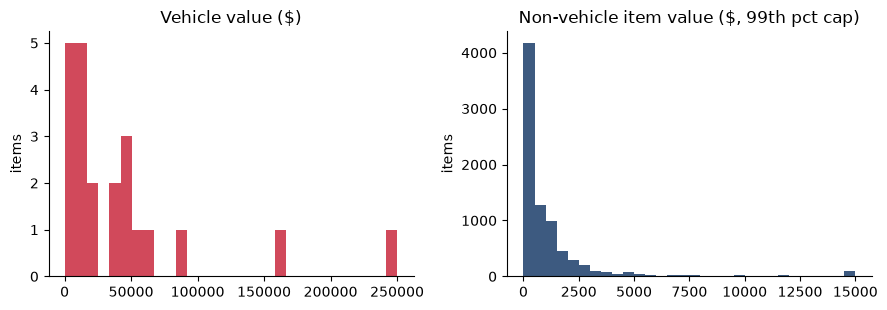

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(v, bins=30, color=RED)
axes[0].set_title("Vehicle value ($)")
axes[1].hist(nv.clip(upper=nv.quantile(.99)), bins=30, color=BLUE)
axes[1].set_title("Non-vehicle item value ($, 99th pct cap)")
for a in axes: a.set_ylabel("items")
plt.tight_layout()
plt.show()

## 4. Properties table

--- Property_Type


,count,share_%
Property_Type,,
house,329,41.4
apartment,188,23.6
terrace,162,20.4
villa,60,7.5
duplex,39,4.9
semi-detached,17,2.1


--- Occupancy_Type


,count,share_%
Occupancy_Type,,
owner,480,60.4
tenant,315,39.6


--- Address_State


...

,count,share_%
Is_Primary,,
True,500,62.9
False,295,37.1


--- Is_Home_Insured


,count,share_%
Is_Home_Insured,,
1,595,74.8
0,137,17.2
2,63,7.9


--- Insurance_Coverage_Type


,count,share_%
Insurance_Coverage_Type,,
home-and-contents-insurance,271,34.1
contents-insurance,223,28.1
NaN,200,25.2
home-insurance,82,10.3
other,11,1.4
landlord-insurance,8,1.0


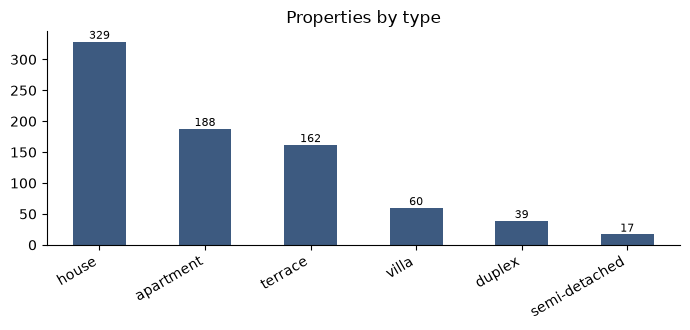

In [11]:
for col in ["Property_Type", "Occupancy_Type", "Address_State", "Is_Primary", "Is_Home_Insured", "Insurance_Coverage_Type"]:
    vc = properties[col].value_counts(dropna=False)
    print(f"--- {col}")
    display(pd.DataFrame({"count": vc, "share_%": (100*vc/len(properties)).round(1)}))
bar(properties.Property_Type.value_counts(), "Properties by type")

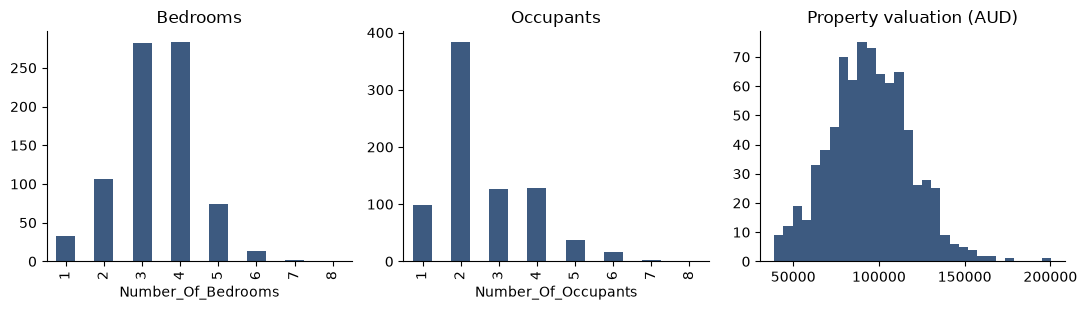

,Number_Of_Occupants,Number_Of_Bedrooms,Property_Valuation_AUD
count,795.0,795.0,795.0
mean,3.0,3.0,94812.0
std,1.0,1.0,23681.0
min,1.0,1.0,38858.0
25%,2.0,3.0,78307.0
50%,2.0,3.0,94479.0
75%,3.0,4.0,110601.0
max,8.0,8.0,200623.0


,count,mean,median
Property_Type,,,
duplex,39,108989.0,108871.0
house,329,101909.0,101888.0
terrace,162,93845.0,92108.0
villa,60,93695.0,92927.0
semi-detached,17,88249.0,88436.0
apartment,188,81234.0,80883.0


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
properties.Number_Of_Bedrooms.value_counts().sort_index().plot.bar(ax=axes[0], color=BLUE, title="Bedrooms")
properties.Number_Of_Occupants.value_counts().sort_index().plot.bar(ax=axes[1], color=BLUE, title="Occupants")
axes[2].hist(properties.Property_Valuation_AUD, bins=30, color=BLUE)
axes[2].set_title("Property valuation (AUD)")
plt.tight_layout()
plt.show()
display(properties[["Number_Of_Occupants", "Number_Of_Bedrooms", "Property_Valuation_AUD"]].describe().round(0))
display(properties.groupby("Property_Type").Property_Valuation_AUD.agg(["count", "mean", "median"]).round(0).sort_values("mean", ascending=False))

## 5. Customers and customer profiles

--- Age_Band


Age_Band,35-44,45-54,25-34,55-64,18-24,65+
count,142.0,118.0,95.0,81.0,42.0,22.0
share_%,28.4,23.6,19.0,16.2,8.4,4.4


--- Gender


Gender,Female,Male,Prefer not to say
count,238.0,236.0,26.0
share_%,47.6,47.2,5.2


--- State


...

Membership_Level,free,plus,premium
count,311.0,127.0,62.0
share_%,62.2,25.4,12.4


--- Account_Status


Account_Status,active,deactivated
count,477.0,23.0
share_%,95.4,4.6


--- Auth_Provider


Auth_Provider,email,google,apple
count,247.0,159.0,94.0
share_%,49.4,31.8,18.8


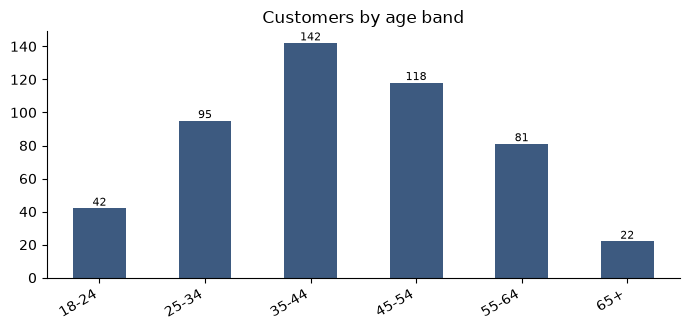

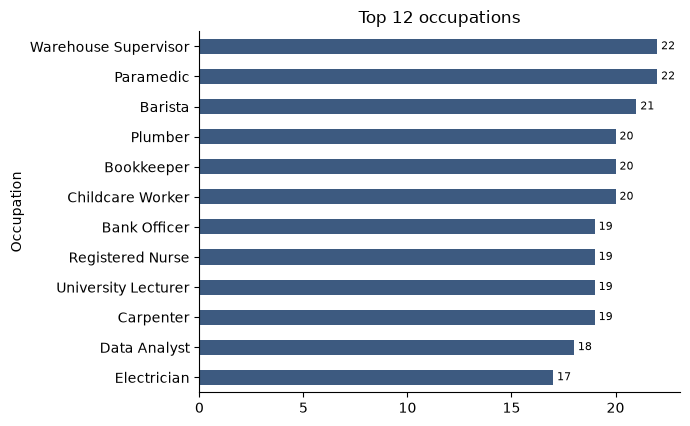

In [13]:
for col in ["Age_Band", "Gender", "State", "Membership_Level", "Account_Status", "Auth_Provider"]:
    vc = customers[col].value_counts()
    print(f"--- {col}")
    display(pd.DataFrame({"count": vc, "share_%": (100*vc/len(customers)).round(1)}).T)
bar(customers.Age_Band.value_counts().sort_index(), "Customers by age band")
bar(customers.Occupation.value_counts().head(12), "Top 12 occupations", horizontal=True)

In [14]:
for col in ["Household_Type", "Income_Band", "Financial_Literacy_Band", "Engagement_Tier", "Prior_Claim_Experience", "Underinsurance_Awareness", "Language_At_Home"]:
    vc = profiles[col].value_counts()
    print(f"--- {col}")
    display(pd.DataFrame({"count": vc, "share_%": (100*vc/len(profiles)).round(1)}).T)
display(profiles[["Insurance_Confidence_1_5", "Tenure_Months", "Churn_Risk_Score"]].describe().round(2))

--- Household_Type


Household_Type,family_with_children,couple_no_children,single,share_house,single_parent
count,173.0,117.0,108.0,53.0,49.0
share_%,34.6,23.4,21.6,10.6,9.8


--- Income_Band


Income_Band,over_150k,100k_150k,75k_100k,50k_75k,under_50k
count,135.0,130.0,85.0,80.0,70.0
share_%,27.0,26.0,17.0,16.0,14.0


--- Financial_Literacy_Band


...

--- Underinsurance_Awareness


Underinsurance_Awareness,unaware,somewhat_aware,well_informed
count,220.0,185.0,95.0
share_%,44.0,37.0,19.0


--- Language_At_Home


Language_At_Home,English,Mandarin,Punjabi,Other,Arabic,Vietnamese,Greek,Cantonese,Italian
count,384.0,23.0,22.0,22.0,14.0,12.0,9.0,7.0,7.0
share_%,76.8,4.6,4.4,4.4,2.8,2.4,1.8,1.4,1.4


,Insurance_Confidence_1_5,Tenure_Months,Churn_Risk_Score
count,500.00,500.00,500.00
mean,3.06,21.77,0.38
std,1.11,12.02,0.21
min,1.00,1.00,0.01
25%,2.00,12.00,0.23
50%,3.00,22.00,0.36
75%,4.00,32.00,0.50
max,5.00,42.00,0.99


## 6. Assets table

items per property (all categories): {'count': 795.0, 'mean': 10.5, 'std': 28.5, 'min': 1.0, '25%': 1.0, '50%': 2.0, '75%': 7.0, 'max': 470.0}
items per property (excl. vehicles): {'count': 795.0, 'mean': 10.4, 'std': 28.5, 'min': 0.0, '25%': 1.0, '50%': 2.0, '75%': 7.0, 'max': 470.0}
properties with < 10 non-vehicle items (skipped by the data preparation): 636


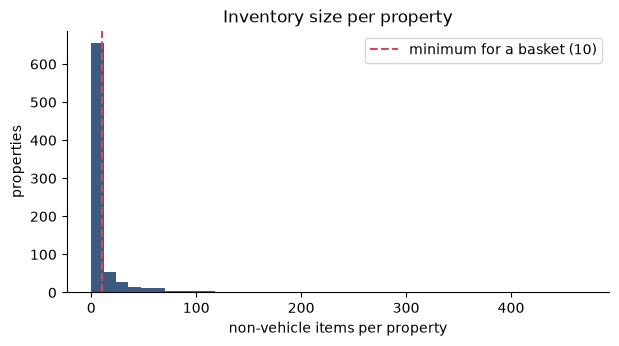

,properties able to give this N,share_of_all_properties_%,rows_at_5_draws
N,,,
10,159,20.0,795
20,102,12.8,510
30,68,8.6,340
50,41,5.2,205


properties with 0 non-vehicle items: 4 | with 1-9 items: 632


In [15]:
items_per_prop = assets.groupby("Property_ID").size()
print("items per property (all categories):", items_per_prop.describe().round(1).to_dict())
contents_per_prop = non.groupby("Property_ID").size().reindex(properties.Property_ID).fillna(0).astype(int)
print("items per property (excl. vehicles):", contents_per_prop.describe().round(1).to_dict())
print(f"properties with < 10 non-vehicle items (skipped by the data preparation): {(contents_per_prop < 10).sum()}")

fig, ax = plt.subplots()
ax.hist(contents_per_prop, bins=40, color=BLUE)
ax.axvline(10, color=RED, ls="--", label="minimum for a basket (10)")
ax.set_xlabel("non-vehicle items per property")
ax.set_ylabel("properties")
ax.legend()
ax.set_title("Inventory size per property")
plt.show()

# Can the basket simulation work? A property can produce samples of size N only if it has >= N non-vehicle items.
feas = pd.DataFrame({"properties able to give this N": {N: int((contents_per_prop >= N).sum()) for N in [10, 20, 30, 50]}})
feas["share_of_all_properties_%"] = (100 * feas.iloc[:, 0] / len(properties)).round(1)
feas["rows_at_5_draws"] = feas.iloc[:, 0] * 5
feas.index.name = "N"
display(feas)
print(f"properties with 0 non-vehicle items: {(contents_per_prop == 0).sum()} | with 1-9 items: {((contents_per_prop > 0) & (contents_per_prop < 10)).sum()}")

,items,avg_value,median_value,total_value,share_of_total_%
Category,,,,,
Electronics,2590,1535.0,700.0,3974783.0,28.8
Jewellery and Personal Items,937,3980.0,800.0,3729714.0,27.0
Furniture,1999,1221.0,450.0,2441200.0,17.7
Appliances,1142,1372.0,799.0,1566535.0,11.3
Vehicles,22,42998.0,19500.0,945950.0,6.8
Other Items,1042,875.0,180.0,911731.0,6.6
Clothings,362,669.0,52.0,242290.0,1.8


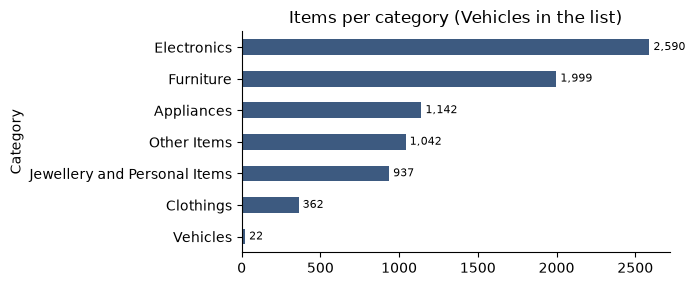

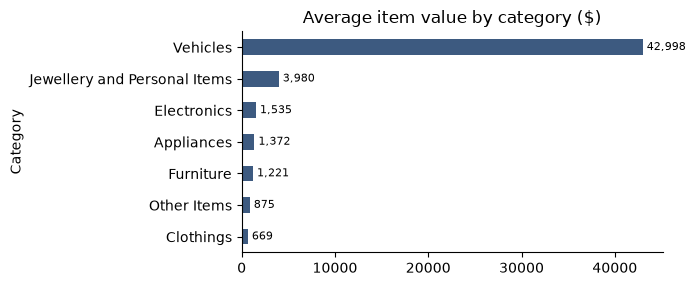

In [16]:
cat = assets.groupby("Category").Current_Estimated_Value.agg(items="count", avg_value="mean", median_value="median", total_value="sum").round(0).sort_values("total_value", ascending=False)
cat["share_of_total_%"] = (100 * cat.total_value / cat.total_value.sum()).round(1)
display(cat)
bar(cat["items"].sort_values(ascending=False), "Items per category (Vehicles in the list)", horizontal=True)
bar(cat.avg_value.sort_values(ascending=False), "Average item value by category ($)", horizontal=True)

In [17]:
for col in ["Condition", "Ownership_Status", "Room", "Is_Specified_Item", "Evidence_Rating_0_5"]:
    vc = assets[col].value_counts().sort_index() if col == "Evidence_Rating_0_5" else assets[col].value_counts()
    print(f"--- {col}")
    display(pd.DataFrame({"count": vc, "share_%": (100*vc/len(assets)).round(1)}).T)

print("missing values:")
display(assets.isna().sum()[lambda s: s > 0].to_frame("nulls").assign(pct=lambda d: (100*d.nulls/len(assets)).round(1)))
print("value columns (all items):")
display(assets[["Purchase_Price", "Replacement_Cost_New", "Current_Estimated_Value"]].describe().round(0))
print("Current value / purchase price (median):", round((assets.Current_Estimated_Value / assets.Purchase_Price.replace(0, np.nan)).median(), 2))

--- Condition


Condition
count
share_%


--- Ownership_Status


Ownership_Status,owned
count,8309.0
share_%,100.0


--- Room


...

missing values:


,nulls,pct
Policy_ID,3476,41.8
Brand,845,10.2
Model,8309,100.0
Year,7261,87.4
Serial_Number,8222,99.0
Purchase_Date,7294,87.8
Purchase_Price,8309,100.0
Replacement_Cost_New,215,2.6
Current_Estimated_Value,215,2.6
Condition,8309,100.0


value columns (all items):


,Purchase_Price,Replacement_Cost_New,Current_Estimated_Value
count,0.0,8094.0,8094.0
mean,NaN,1835.0,1706.0
std,NaN,9537.0,9641.0
min,NaN,1.0,1.0
25%,NaN,169.0,160.0
50%,NaN,500.0,500.0
75%,NaN,1500.0,1400.0
max,NaN,420000.0,500000.0


Current value / purchase price (median): nan


## 7. Contents value of a home (the model target) vs property and customer attributes

The target `true_total_value` is the sum of `Current_Estimated_Value` over the **non-vehicle** items of a home, which is exactly what Block 3 of the data preparation notebook builds.

{'count': 791.0, 'mean': 16266.0, 'std': 70928.0, 'min': 0.0, '25%': 1200.0, '50%': 3099.0, '75%': 11323.0, 'max': 1349866.0}


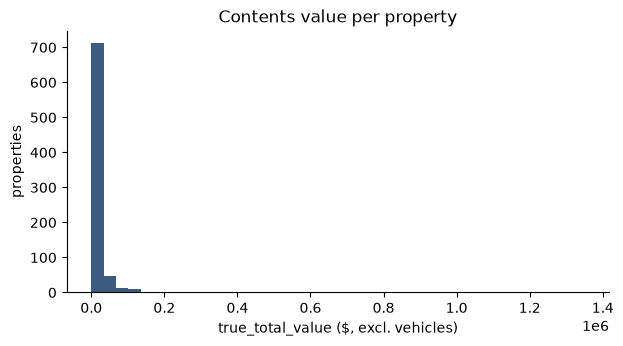

,true_total_value,n_items,Number_Of_Bedrooms,Number_Of_Occupants,Property_Valuation_AUD,vehicle_value
Spearman correlation,,,,,,
true_total_value,1.0,0.79,0.42,0.29,0.44,0.1


In [18]:
tv = non.groupby("Property_ID").Current_Estimated_Value.sum().rename("true_total_value")
home = properties.merge(tv, on="Property_ID", how="left").merge(customers[["Customer_ID", "Age_Band", "Membership_Level"]], on="Customer_ID") \
                 .merge(profiles[["Customer_ID", "Income_Band", "Household_Type"]], on="Customer_ID")
home["n_items"] = home.Property_ID.map(contents_per_prop)
home["vehicle_value"] = home.Property_ID.map(vp).fillna(0)
print(home.true_total_value.describe().round(0).to_dict())

fig, ax = plt.subplots()
ax.hist(home.true_total_value, bins=40, color=BLUE)
ax.set_xlabel("true_total_value ($, excl. vehicles)")
ax.set_ylabel("properties")
ax.set_title("Contents value per property")
plt.show()

num = home[["true_total_value", "n_items", "Number_Of_Bedrooms", "Number_Of_Occupants", "Property_Valuation_AUD", "vehicle_value"]]
display(num.corr(method="spearman").round(2)[["true_total_value"]].T.rename_axis("Spearman correlation"))

In [19]:
def by(col, order=None):
    g = home.groupby(col).true_total_value.agg(properties="count", mean="mean", median="median").round(0)
    return g.loc[order] if order else g.sort_values("mean", ascending=False)

for col in ["Property_Type", "Occupancy_Type", "Number_Of_Bedrooms", "Number_Of_Occupants", "Income_Band", "Household_Type", "Age_Band", "Membership_Level"]:
    print(f"--- mean contents value by {col}")
    display(by(col))

--- mean contents value by Property_Type


,properties,mean,median
Property_Type,,,
duplex,39,26471.0,6447.0
house,327,19481.0,2899.0
terrace,160,19453.0,4000.0
villa,60,11593.0,2350.0
apartment,188,8219.0,2874.0
semi-detached,17,6482.0,4239.0


--- mean contents value by Occupancy_Type


,properties,mean,median
Occupancy_Type,,,
owner,478,22209.0,4500.0
tenant,313,7190.0,2200.0


--- mean contents value by Number_Of_Bedrooms


...

,properties,mean,median
Household_Type,,,
share_house,95,25524.0,2929.0
couple_no_children,192,24442.0,3500.0
family_with_children,251,15658.0,5099.0
single,178,7222.0,2450.0
single_parent,75,7105.0,2300.0


--- mean contents value by Age_Band


,properties,mean,median
Age_Band,,,
55-64,133,26041.0,3100.0
65+,27,17409.0,7701.0
25-34,153,16140.0,3400.0
35-44,223,15288.0,2799.0
45-54,187,13440.0,3448.0
18-24,68,7952.0,2832.0


--- mean contents value by Membership_Level


,properties,mean,median
Membership_Level,,,
free,504,18293.0,3200.0
plus,190,13127.0,3000.0
premium,97,11881.0,3000.0


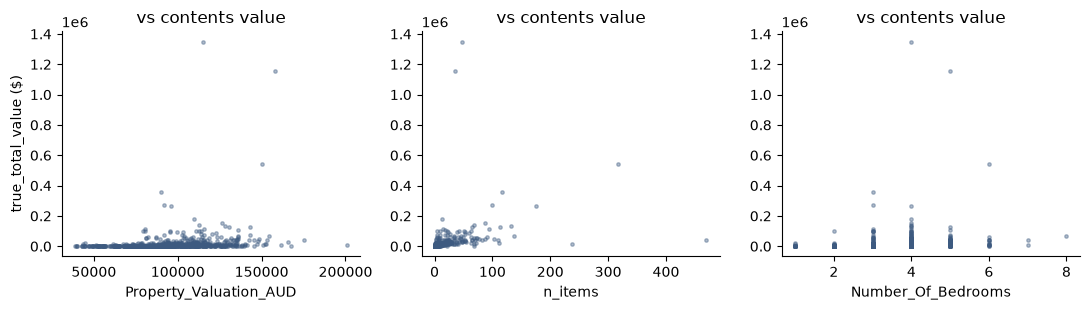

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, ["Property_Valuation_AUD", "n_items", "Number_Of_Bedrooms"]):
    ax.scatter(home[col], home.true_total_value, s=6, alpha=.4, color=BLUE)
    ax.set_xlabel(col)
    ax.set_title("vs contents value")
axes[0].set_ylabel("true_total_value ($)")
plt.tight_layout()
plt.show()

## 8. All tabs in the workbook

The workbook has many more tables than the four analysed above (AI analysis, valuations, policies, claims, notifications, …). Row and column counts come from the workbook's own `Contents` tab.

In [21]:
display(pd.read_excel(XLSX, sheet_name="Contents").iloc[:, :5])

,Tab,Rows,Columns,Maps to production entity,Status
0,customers,500,15,User,Production
1,customer_profiles,500,15,— (challenge extension),Extension
2,properties,795,19,Property,Production
3,base_categories,7,9,BaseCategory,Production
4,assets,8309,25,PropertyItem,Production
5,asset_images,8309,13,PropertyItem.imageUrl / image records,Production
6,asset_attachments,2049,13,PropertyItemAttachment,Production
7,ai_analysis,24634,25,ImageAnalysis + OpenAILog,Production
8,valuations,8094,10,PropertyItem.value,Extension
9,property_videos,219,11,PropertyVideo,Production


## What to take from the exploration

All numbers in this notebook are computed live, and the points below describe what to look for in them.

- **Households versus customers:** Compare the number of properties with the number of customers. A customer with several properties has several separate homes, each with its own inventory, and the model treats each property as one household.
- **Vehicles:** Compare the average vehicle value with the average non-vehicle item value, and look at the share of properties that own a vehicle. The data preparation notebook removes the `Vehicles` category before building the target.
- **Inventory size per property:** This decides which basket sizes N can be simulated. A home can only supply N items if it owns at least N, so the table of properties able to give each N shows how much data each basket size has.
- **Contents value:** The contents value per property is strongly right-skewed. The correlation and group tables show which property and customer attributes carry a signal.